# 单 CV `Cell` 能否替代 `SingleCompartment`？

可以，但不是直接改一个类名。只含一个 CV 的 `Cell(pop_size=(N,))` 能表示一组单室神经元，也能独立组成完整网络；当几何、电容、通道、初值、电流和求解器一致时，它与 `SingleCompartment` 给出相同的单室方程。

`Cell` 的优势是接口完整：声明式机制、clamp、point synapse、连接、结构化记录、空间选择和可训练参数都使用同一套运行时。迁移时仍需注意状态 shape 从 `(N,)` 变为 `(N, 1)`，外部电流从 `update(I_ext)` 改为 clamp，以及自定义机制需要注册。

| 对比项 | `SingleCompartment` | 单 CV `Cell` |
|---|---|---|
| 电压 shape | `(N,)` | `(N, 1)` |
| 电流输入 | `update(I_ext)` | clamp 或 input binding |
| 通道配置 | 子类中组装对象 | `paint()` 声明 |
| point synapse / connection | 外部组合 | 原生支持 |
| 记录 | 用户循环 | schema 化 `record()` |
| 新版 `Network` | 不满足完整 cell contract | 支持 |
| 空间扩展 | 无 | 可继续增加 branch 和 CV |


In [1]:
import time

import brainstate
import braintools
import brainunit as u
import jax
import matplotlib.pyplot as plt
import numpy as np

import braincell
from braincell.filter import AllRegion, RootLocation, at

plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP"]
plt.rcParams["axes.unicode_minus"] = False

DT = 0.025 * u.ms
SOMA_LENGTH = 20.0 * u.um
SOMA_RADIUS = 10.0 * u.um
SOMA_AREA = 2.0 * u.math.pi * SOMA_RADIUS * SOMA_LENGTH
CURRENT_DENSITY = 10.0 * u.uA / u.cm**2
TOTAL_CURRENT = (CURRENT_DENSITY * SOMA_AREA).in_unit(u.nA)

print(f"backend={jax.default_backend()}, x64={jax.config.jax_enable_x64}")
print(f"膜面积={SOMA_AREA.in_unit(u.um**2)}, 等效总电流={TOTAL_CURRENT}")

backend=gpu, x64=False
膜面积=1256.6371 um^2, 等效总电流=0.12566371 nA


In [2]:
class LegacyPassive(braincell.SingleCompartment):
    def __init__(self, size, *, solver="rk4"):
        super().__init__(
            size,
            length=SOMA_LENGTH,
            radius=SOMA_RADIUS,
            C=1.0 * u.uF / u.cm**2,
            V_initializer=braintools.init.Constant(-65.0 * u.mV),
            solver=solver,
        )
        self.leak = braincell.channel.IL(size, g_max=0.3 * u.mS / u.cm**2, E=-54.3 * u.mV)


class LegacyHH(LegacyPassive):
    def __init__(self, size, *, solver="rk4"):
        super().__init__(size, solver=solver)
        self.na = braincell.ion.SodiumFixed(size, E=50.0 * u.mV)
        self.na.add(na=braincell.channel.Na_HH1952(size, g_max=120.0 * u.mS / u.cm**2))
        self.k = braincell.ion.PotassiumFixed(size, E=-77.0 * u.mV)
        self.k.add(k=braincell.channel.K_HH1952(size, g_max=36.0 * u.mS / u.cm**2))


def make_soma():
    soma = braincell.Branch.from_lengths(
        lengths=[20.0] * u.um,
        radii=[10.0, 10.0] * u.um,
        type="soma",
    )
    return braincell.Morphology.from_root(soma, name="soma")


def build_one_cv_cell(size, *, active, solver="rk4", clamp=None, synapse=False):
    cell = braincell.Cell(
        make_soma(),
        pop_size=(size,),
        cv_policy=braincell.CVPerBranch(),
        V_init=-65.0 * u.mV,
        V_th=0.0 * u.mV,
        solver=solver,
    )
    mechanisms = [
        braincell.mech.CableProperty(
            resting_potential=-54.3 * u.mV,
            membrane_capacitance=1.0 * u.uF / u.cm**2,
            axial_resistivity=100.0 * u.ohm * u.cm,
        ),
        braincell.mech.Channel("IL", name="leak", g_max=0.3 * u.mS / u.cm**2, E=-54.3 * u.mV),
    ]
    if active:
        mechanisms += [
            braincell.mech.Ion("SodiumFixed", E=50.0 * u.mV),
            braincell.mech.Ion("PotassiumFixed", E=-77.0 * u.mV),
            braincell.mech.Channel("Na_HH1952", name="na", g_max=120.0 * u.mS / u.cm**2),
            braincell.mech.Channel("K_HH1952", name="k", g_max=36.0 * u.mS / u.cm**2),
        ]
    cell.paint(AllRegion(), *mechanisms)
    if clamp is not None:
        cell.place(RootLocation(0.5), clamp)
    if synapse:
        cell.place(
            at("soma", 0.5),
            braincell.mech.Synapse("ExpSyn", name="ampa", tau=2.0 * u.ms, e=0.0 * u.mV),
        )
    cell.record("v", braincell.observe.state("v"))
    return cell

## 数值等价

下面使用相同的圆柱面积、膜电容、反转电位、最大电导、初值、RK4 和电流密度。`SingleCompartment` 接收电流密度；`Cell` 的 clamp 接收由膜面积换算得到的总电流。两者都在记录前执行相同意义的 state reset。


电压 shape: (4,) -> (4, 1)
Passive 最大差值: 0 mV
HH 电压 RMSE:     1.89739e-07 mV
Spike time (ms):  [1.9] -> [1.9]


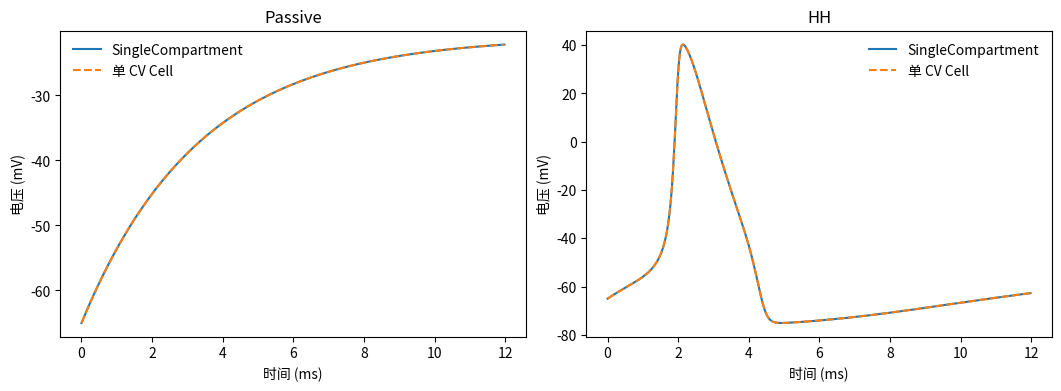

In [3]:
def run_legacy(model, duration):
    model.init_state()
    model.reset_state()
    times = u.math.arange(0.0 * u.ms, duration, DT)

    def step(t):
        with brainstate.environ.context(t=t):
            model.update(CURRENT_DENSITY)
        return model.V.value

    with brainstate.environ.context(dt=DT):
        post_step = brainstate.transform.for_loop(step, times)
    initial = np.full((1, model.pop_size[0]), -65.0)
    voltage = np.concatenate([initial, np.asarray(post_step.to_decimal(u.mV))[:-1]], axis=0)
    return np.asarray(times.to_decimal(u.ms)), voltage


def run_cell(cell, duration):
    result = cell.run(dt=DT, duration=duration)
    return (
        np.asarray(result.samples["v"].time.to_decimal(u.ms)),
        np.asarray(result.samples["v"].values.to_decimal(u.mV)),
    )


def upward_crossings(times, voltage, threshold=0.0):
    voltage = np.asarray(voltage).reshape(-1)
    rows = np.flatnonzero((voltage[:-1] < threshold) & (voltage[1:] >= threshold)) + 1
    return np.asarray(times)[rows]


shape_legacy = LegacyPassive(4)
shape_legacy.init_state()
shape_cell = build_one_cv_cell(4, active=False)
shape_cell.init_state()
print("电压 shape:", shape_legacy.V.value.shape, "->", shape_cell.V.value.shape)

DURATION = 12.0 * u.ms
comparisons = {}
for label, legacy_type, active in (
    ("Passive", LegacyPassive, False),
    ("HH", LegacyHH, True),
):
    legacy_t, legacy_v = run_legacy(legacy_type(1), DURATION)
    cell_t, cell_v = run_cell(
        build_one_cv_cell(
            1,
            active=active,
            clamp=braincell.mech.CurrentClamp(durations=DURATION, amplitudes=TOTAL_CURRENT),
        ),
        DURATION,
    )
    comparisons[label] = legacy_t, legacy_v[:, 0], cell_t, cell_v[:, 0]

passive = comparisons["Passive"]
active = comparisons["HH"]
passive_max_error = np.max(np.abs(passive[3] - passive[1]))
active_rmse = np.sqrt(np.mean((active[3] - active[1]) ** 2))
legacy_spikes = upward_crossings(active[0], active[1])
cell_spikes = upward_crossings(active[2], active[3])

print(f"Passive 最大差值: {passive_max_error:.6g} mV")
print(f"HH 电压 RMSE:     {active_rmse:.6g} mV")
print("Spike time (ms): ", legacy_spikes, "->", cell_spikes)

figure, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), constrained_layout=True)
for axis, (label, values) in zip(axes, comparisons.items()):
    legacy_t, legacy_v, cell_t, cell_v = values
    axis.plot(legacy_t, legacy_v, label="SingleCompartment")
    axis.plot(cell_t, cell_v, "--", label="单 CV Cell")
    axis.set(title=label, xlabel="时间 (ms)", ylabel="电压 (mV)")
    axis.legend(frameon=False)
plt.show()

## 只由单 CV Cell 组成的网络

下面的 pre 和 post 都是三成员的单 CV HH population。三种 clamp 幅度产生不同的放电时间，再通过一对一 `ExpSyn` connection 驱动 post；网络中不需要任何多 CV 神经元。


Network(name='one_cv_only', populations=2, connections=1, rows=3)
  populations:
    pre: size=3, kind=cell, model=Cell, initialized=True
    post: size=3, kind=cell, model=Cell, initialized=True
  connections:
    post: connections=1, rows=3
      drive: CellSpikeSource(Cell.spike) -> ExpSyn(ampa), rows=3
记录 shape: (800, 3) (800, 3)
事件数量: 3 3


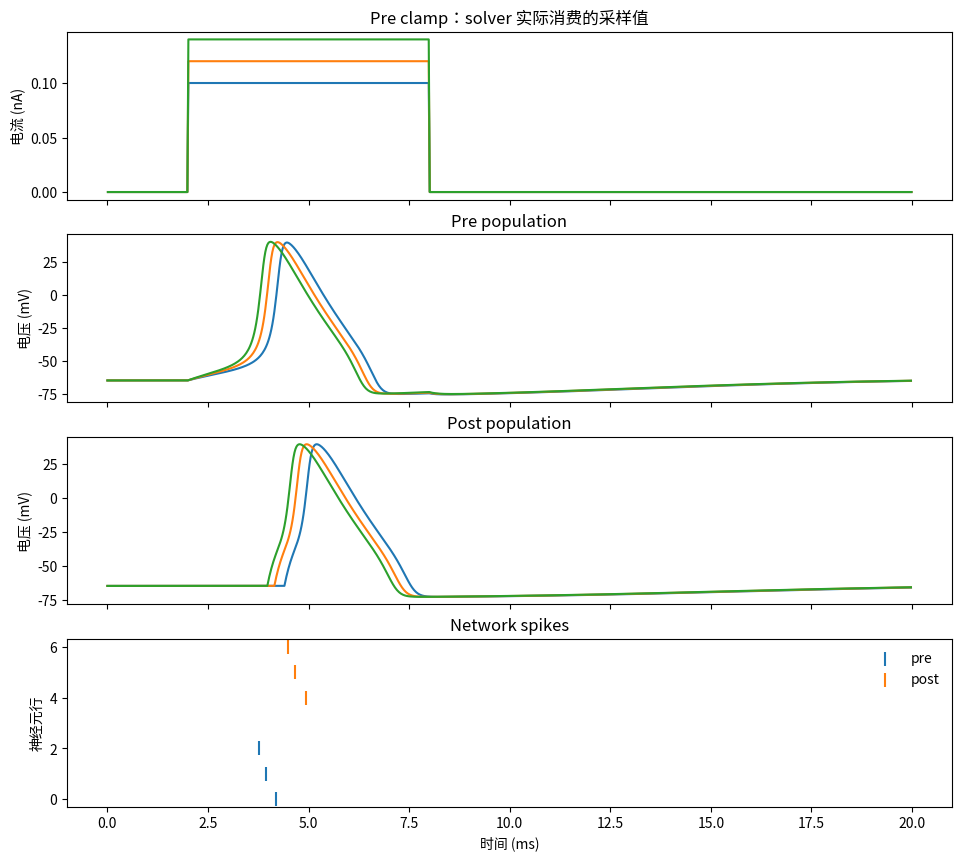

In [4]:
pre_clamp = braincell.mech.CurrentClamp(
    delay=2.0 * u.ms,
    durations=6.0 * u.ms,
    amplitudes=np.asarray([0.10, 0.12, 0.14]) * u.nA,
)
pre_cell = build_one_cv_cell(3, active=True, solver="staggered", clamp=pre_clamp)
post_cell = build_one_cv_cell(3, active=True, solver="staggered", synapse=True)
pre_cell.clamps.record("input")

network = braincell.Network("one_cv_only")
pre = network.add_population("pre", pre_cell)
post = network.add_population("post", post_cell)
network.connect(
    "drive",
    source=pre.event_outputs["spike"],
    synapse=post.synapses["ampa"],
    weight=0.03 * u.uS,
    delay=0.2 * u.ms,
)
network_result = network.run(dt=DT, duration=20.0 * u.ms)

pre_v = network_result.samples["pre"]["v"]
post_v = network_result.samples["post"]["v"]
input_block = network_result.samples["pre"]["input"]
pre_events = network_result.events["pre"]["spike"]
post_events = network_result.events["post"]["spike"]

print(network)
print("记录 shape:", pre_v.values.shape, post_v.values.shape)
print("事件数量:", len(pre_events.time), len(post_events.time))

figure, axes = plt.subplots(4, 1, figsize=(9.5, 8.5), sharex=True, constrained_layout=True)
axes[0].plot(input_block.time.to_decimal(u.ms), input_block.values.to_decimal(u.nA))
axes[0].set(ylabel="电流 (nA)", title="Pre clamp：solver 实际消费的采样值")
axes[1].plot(pre_v.time.to_decimal(u.ms), pre_v.values.to_decimal(u.mV))
axes[1].set(ylabel="电压 (mV)", title="Pre population")
axes[2].plot(post_v.time.to_decimal(u.ms), post_v.values.to_decimal(u.mV))
axes[2].set(ylabel="电压 (mV)", title="Post population")
axes[3].scatter(pre_events.time.to_decimal(u.ms), pre_events.source_id, marker="|", s=100, label="pre")
axes[3].scatter(
    post_events.time.to_decimal(u.ms),
    post_events.source_id + pre.size + 1,
    marker="|",
    s=100,
    label="post",
)
axes[3].set(xlabel="时间 (ms)", ylabel="神经元行", title="Network spikes")
axes[3].legend(frameon=False)
plt.show()

## Point 放置与 solver 语义

一个单 CV branch 仍包含 proximal boundary、CV midpoint 和 distal boundary 三个 electrical point。staggered/DHS 会保留完整 point 电压：endpoint clamp 直接进入边界方程，endpoint synapse 的 `g(E-V_point)` 也在该 point 上线性化，因此电导项进入对角线、反转电位项进入 RHS。突触电流记录读取的也是 solver 实际使用的 point 电压。

显式 RK solver 目前只演化 CV midpoint 电压，尚未定义 endpoint point state 和 RK stage 内的再次采样；该扩展仍是 TODO。下面的 clamp 对比直接展示当前差异。


    solver      位置   CV role    point    CV
 staggered    prox      prox        0     0
 staggered     mid       mid        1     0
 staggered    dist      dist        2     0
       rk4    prox      prox        0     0
       rk4     mid       mid        1     0
       rk4    dist      dist        2     0


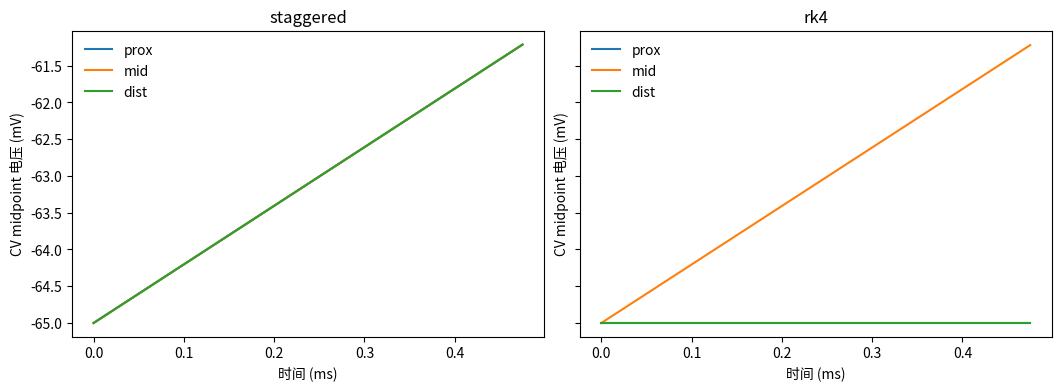

In [5]:
POSITIONS = {"prox": 0.0, "mid": 0.5, "dist": 1.0}


def location_clamp_cell(branch_x, solver):
    cell = braincell.Cell(
        make_soma(),
        pop_size=(1,),
        cv_policy=braincell.CVPerBranch(),
        V_init=-65.0 * u.mV,
        solver=solver,
    )
    cell.place(
        RootLocation(branch_x),
        braincell.mech.CurrentClamp(durations=0.5 * u.ms, amplitudes=0.1 * u.nA),
    )
    cell.record("v", braincell.observe.state("v"))
    return cell


placement_rows = []
placement_traces = {}
for solver in ("staggered", "rk4"):
    for position, branch_x in POSITIONS.items():
        cell = location_clamp_cell(branch_x, solver)
        placement = cell.point_placements[0]
        result = cell.run(dt=DT, duration=0.5 * u.ms)
        placement_rows.append((solver, position, placement.cv_position, placement.point_id, placement.cv_id))
        placement_traces[solver, position] = (
            result.samples["v"].time.to_decimal(u.ms),
            result.samples["v"].values.to_decimal(u.mV)[:, 0],
        )

print(f"{'solver':>10}  {'位置':>6}  {'CV role':>8}  {'point':>7}  {'CV':>4}")
for solver, position, role, point_id, cv_id in placement_rows:
    print(f"{solver:>10}  {position:>6}  {role:>8}  {point_id:7d}  {cv_id:4d}")

figure, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharey=True, constrained_layout=True)
for axis, solver in zip(axes, ("staggered", "rk4")):
    for position in POSITIONS:
        time_ms, voltage_mv = placement_traces[solver, position]
        axis.plot(time_ms, voltage_mv, label=position)
    axis.set(title=solver, xlabel="时间 (ms)", ylabel="CV midpoint 电压 (mV)")
    axis.legend(frameon=False)
plt.show()

## 性能审计

这里比较构建、初始化、warm-up、reset 和纯运行时间，并分别统计 differential、auxiliary 与 runtime parameter state。每个纯运行样本都在 `reset_state()` 完成并同步之后开始；三次 warm-up 用于吸收 tracing/compilation，表中 steady 值是五次同步调用的中位数。结果只描述当前机器和当前 backend，不是发布基准。


计时（run 不含 reset）：
     N               model      build       init    warm-up      reset        run    us/step
     1   SingleCompartment       2.40       5.33     823.09     33.311      4.338     21.690
     1           单 CV Cell       7.28     100.70    1789.42     44.615     12.806     64.031
     8   SingleCompartment       1.97     157.38     792.55     92.809      2.771     13.857
     8           单 CV Cell      18.76    1572.01    1842.24    156.533      9.517     47.585
    32   SingleCompartment       2.35     209.85     872.49    289.827      2.868     14.341
    32           单 CV Cell      10.69    1877.38    1567.42    529.815     12.630     63.149
   128   SingleCompartment       2.76     162.97     818.84     74.711      3.747     18.737
   128           单 CV Cell      14.36    1388.31    1505.26    124.125     10.141     50.705
   512   SingleCompartment       1.95     204.35    1170.97     96.992      3.944     19.722
   512           单 CV Cell       7.76    1459.41    

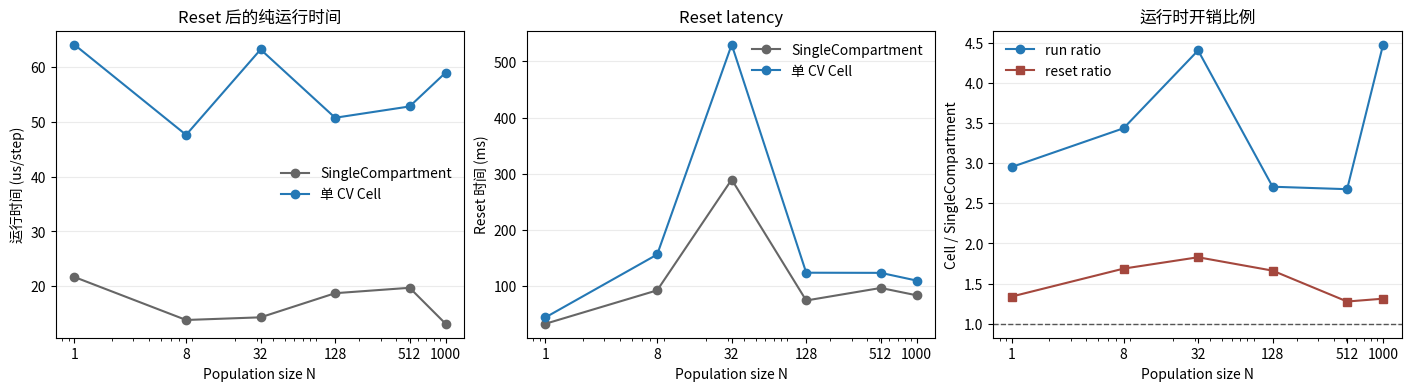

In [6]:
def state_elements(model):
    counts = {"differential": 0, "auxiliary": 0, "runtime_parameter": 0}
    for state in brainstate.graph.states(model).values():
        name = type(state).__name__
        category = (
            "differential"
            if name.startswith("DiffEq")
            else "runtime_parameter"
            if name == "RuntimeParameterState"
            else "auxiliary"
        )
        counts[category] += int(np.size(u.get_mantissa(state.value)))
    counts["total"] = sum(counts.values())
    return counts


def synchronize(model):
    jax.block_until_ready(tuple(state.value for state in brainstate.graph.states(model).values()))


def elapsed(call):
    started = time.perf_counter()
    output = call()
    jax.block_until_ready(output)
    return time.perf_counter() - started


def benchmark(size, duration=5.0 * u.ms, warmups=3, repeats=5):
    started = time.perf_counter()
    legacy = LegacyHH(size)
    legacy_build = time.perf_counter() - started
    started = time.perf_counter()
    legacy.init_state()
    legacy_init = time.perf_counter() - started
    times = u.math.arange(0.0 * u.ms, duration, DT)

    def legacy_run():
        def step(t):
            with brainstate.environ.context(t=t):
                legacy.update(CURRENT_DENSITY)
            return legacy.V.value

        with brainstate.environ.context(dt=DT):
            return brainstate.transform.for_loop(step, times)

    legacy_runner = brainstate.transform.jit(legacy_run)

    started = time.perf_counter()
    cell = build_one_cv_cell(
        size,
        active=True,
        clamp=braincell.mech.CurrentClamp(durations=duration, amplitudes=TOTAL_CURRENT),
    )
    cell_build = time.perf_counter() - started
    started = time.perf_counter()
    cell.init_state()
    cell_init = time.perf_counter() - started

    rows = []
    for label, model, runner, build_s, init_s in (
        ("SingleCompartment", legacy, legacy_runner, legacy_build, legacy_init),
        ("单 CV Cell", cell, lambda: cell.run(dt=DT, duration=duration), cell_build, cell_init),
    ):

        def reset():
            model.reset_state()
            synchronize(model)

        def run_after_reset():
            reset()
            return elapsed(runner)

        warmup_s = [run_after_reset() for _ in range(warmups)]
        reset_s = [elapsed(reset) for _ in range(repeats)]
        run_s = [run_after_reset() for _ in range(repeats)]
        run_median = float(np.median(run_s))
        rows.append(
            {
                "size": size,
                "model": label,
                "build_ms": 1e3 * build_s,
                "init_ms": 1e3 * init_s,
                "warmup_ms": 1e3 * sum(warmup_s),
                "reset_ms": 1e3 * float(np.median(reset_s)),
                "run_ms": 1e3 * run_median,
                "us_per_step": 1e6 * run_median / len(times),
                **state_elements(model),
            }
        )
    return rows


SIZES = (1, 8, 32, 128, 512, 1000)
benchmark_rows = [row for size in SIZES for row in benchmark(size)]

print("计时（run 不含 reset）：")
print(f"{'N':>6}  {'model':>18}  {'build':>9}  {'init':>9}  {'warm-up':>9}  {'reset':>9}  {'run':>9}  {'us/step':>9}")
for row in benchmark_rows:
    print(
        f"{row['size']:6d}  {row['model']:>18}  {row['build_ms']:9.2f}  "
        f"{row['init_ms']:9.2f}  {row['warmup_ms']:9.2f}  {row['reset_ms']:9.3f}  "
        f"{row['run_ms']:9.3f}  {row['us_per_step']:9.3f}"
    )

print("\nState 元素数量：")
print(f"{'N':>6}  {'model':>18}  {'differential':>14}  {'auxiliary':>10}  {'runtime':>10}  {'total':>8}")
for row in benchmark_rows:
    print(
        f"{row['size']:6d}  {row['model']:>18}  {row['differential']:14d}  "
        f"{row['auxiliary']:10d}  {row['runtime_parameter']:10d}  {row['total']:8d}"
    )

by_model = {
    model: [row for row in benchmark_rows if row["model"] == model] for model in ("SingleCompartment", "单 CV Cell")
}
legacy_rows = by_model["SingleCompartment"]
cell_rows = by_model["单 CV Cell"]
run_ratios = [cell["us_per_step"] / legacy["us_per_step"] for legacy, cell in zip(legacy_rows, cell_rows)]
reset_ratios = [cell["reset_ms"] / legacy["reset_ms"] for legacy, cell in zip(legacy_rows, cell_rows)]

colors = {"SingleCompartment": "#666666", "单 CV Cell": "#2478b5"}
figure, axes = plt.subplots(1, 3, figsize=(14.0, 3.8), constrained_layout=True)
for model, rows in by_model.items():
    axes[0].plot(SIZES, [row["us_per_step"] for row in rows], marker="o", label=model, color=colors[model])
    axes[1].plot(SIZES, [row["reset_ms"] for row in rows], marker="o", label=model, color=colors[model])
axes[2].plot(SIZES, run_ratios, marker="o", label="run ratio", color="#2478b5")
axes[2].plot(SIZES, reset_ratios, marker="s", label="reset ratio", color="#a4473d")
axes[2].axhline(1.0, color="#555555", linewidth=1.0, linestyle="--")
for axis in axes:
    axis.set_xscale("log")
    axis.set_xticks(SIZES)
    axis.set_xticklabels(SIZES)
    axis.set_xlabel("Population size N")
    axis.grid(axis="y", alpha=0.25)
    axis.legend(frameon=False)
axes[0].set(ylabel="运行时间 (us/step)", title="Reset 后的纯运行时间")
axes[1].set(ylabel="Reset 时间 (ms)", title="Reset latency")
axes[2].set(ylabel="Cell / SingleCompartment", title="运行时开销比例")
plt.show()

## 结论

新的单室模型优先使用单 CV `Cell`：它能组成完整网络，并与未来的多 CV 形态共享机制、连接、记录和训练接口。保留 `(population, n_cv)` 而不自动压掉长度为 1 的 CV 轴，可以避免 shape 随形态变化。

它还不是 `SingleCompartment` 的无缝替换：构造方式、直接电流输入、自定义机制注册和部分显式 solver 的 point 语义仍不同。后续最有价值的简化是提供 `Cell.single(...)` 工厂，自动创建单 branch、`CVPerBranch()` 和默认中心位置，而不是维护第二套运行时。
